# <a id='toc1_'></a>[<span style="color:yellow;">What is a Corner Point in an Image?</span>](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [<span style="color:yellow;">What is a Corner Point in an Image?</span>](#toc1_)    
- [Step 0: Introduction](#toc2_)    
  - [Step 0.1: Measure Intensity Change](#toc2_1_)    
  - [Step 0.2: Structure Tensor (Captures Direction)](#toc2_2_)    
  - [Step 0.3: Eigenvalue](#toc2_3_)    
- [Step 1: Import Libraries](#toc3_)    
- [Step 2: Load Image](#toc4_)    
- [Step 3: Preprocess](#toc5_)    
  - [Step 3.1: Resize the Image](#toc5_1_)    
  - [Step 3.2: Convert to Grayscale](#toc5_2_)    
  - [Step 3.3: Verify Preprocessing Results](#toc5_3_)    
- [Step 4: Corner Response Calculation](#toc6_)    
  - [Step 4.1: Understand the Harris Response Formula](#toc6_1_)    
  - [Step 4.2: Calculate the Corner Response Matrix](#toc6_2_)    
  - [Step 4.3: Visualize the Response Matrix](#toc6_3_)    
  - [Step 4.4: Analyze Response Matrix Properties](#toc6_4_)    
- [Step 5: Extract Corner Peaks](#toc7_)    
  - [Step 5.1: What are Corner Peaks?](#toc7_1_)    
  - [Step 5.2: Configure Peak Detection Parameters](#toc7_2_)    
  - [Step 5.3: Visualize Peak Selection](#toc7_3_)    
  - [Step 5.4: Analyze Detected Corners](#toc7_4_)    
- [Step 6: Visualize Corners with High-Contrast Markers](#toc8_)    
  - [Step 6.1: Choose Marker Style for Visibility](#toc8_1_)    
  - [Step 6.2: Overlay Corners on the Resized Image](#toc8_2_)    
- [Step 7: Analyze Valid ROIs](#toc9_)    
  - [Step 7.1: Define Key Regions of Interest (ROIs)](#toc9_1_)    
  - [Step 7.2: Display the image with ROIs](#toc9_2_)    
  - [Step 7.3: ROI Feature Targets Reference Table](#toc9_3_)    
  - [Step 7.4: Verify ROI Coordinates](#toc9_4_)    
  - [Step 7.5: Visualize Corners in Each ROI](#toc9_5_)    
  - [Step 7.6: Analyze and Interpret ROI Results](#toc9_6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Step 0: Introduction](#toc0_)

## <a id='toc2_1_'></a>[Step 0.1: Measure Intensity Change](#toc0_)
When a window shifts by $(u,v)$, total intensity change is:
$$E(u,v)=∑w(x,y)⋅[I(x+u,y+v)−I(x,y)]^2$$
where $E(u,v)$: Change amount; $I(x,y)$: Pixel intensity; $w(x,y)$: Noise-reducing weight.

## <a id='toc2_2_'></a>[Step 0.2: Structure Tensor (Captures Direction)](#toc0_)
Simplify $E(u,v)$ to see `directionality`<br>
—relies on this tensor:<br>
$$M = \sum w(x,y) \cdot \begin{bmatrix} \left(\frac{\partial I}{\partial x}\right)^2 & \frac{\partial I}{\partial x}\frac{\partial I}{\partial y} \\ \frac{\partial I}{\partial x}\frac{\partial I}{\partial y} & \left(\frac{\partial I}{\partial y}\right)^2 \end{bmatrix}$$
## <a id='toc2_3_'></a>[Step 0.3: Eigenvalue](#toc0_)
$M$ has two `eigenvalues` $(\lambda_1, \lambda_2)$.

* `Corner`: Both $\lambda_1, \lambda_2$ are large (change in 2 directions).

* `Edge`: One large, one small.

* `Flat`: Both small.

# <a id='toc3_'></a>[Step 1: Import Libraries](#toc0_)

In [76]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import data
from PIL import Image
from skimage.feature import corner_harris, corner_peaks

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
%matplotlib inline

print("✅ Step 1: Libraries imported")
print("Using 'coffee' image with improved corner detection\n")

✅ Step 1: Libraries imported
Using 'coffee' image with improved corner detection



# <a id='toc4_'></a>[Step 2: Load Image](#toc0_)

In [77]:
img_rgb = data.coffee()  # Original RGB image
# img_rgb = Image.open("blueberry_cake.png")  # Load image using PIL
# img_rgb = np.array(img_rgb)  # Convert to NumPy array

print("✅ Step 2: Image loaded")
print(f"Original shape: {img_rgb.shape} (height x width x channels)")

✅ Step 2: Image loaded
Original shape: (400, 600, 3) (height x width x channels)


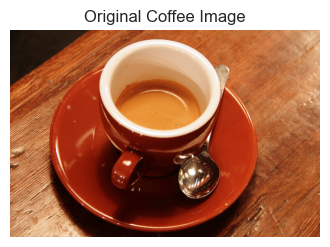

In [78]:
plt.figure(figsize=(4, 3))
plt.imshow(img_rgb)
plt.title("Original Coffee Image")
plt.axis("off")
plt.show()

# <a id='toc5_'></a>[Step 3: Preprocess](#toc0_)
(Resize + Grayscale)

## <a id='toc5_1_'></a>[Step 3.1: Resize the Image](#toc0_)
Resize to a maximum of 256x256 pixels to speed up processing while preserving aspect ratio (avoids stretching/distorting the image).

In [79]:
max_size = 256
h, w = img_rgb.shape[:2]  # Get original height (h) and width (w)
scale = min(max_size / h, max_size / w)  # Calculate scaling factor to fit max_size
img_rgb_resized = cv2.resize(
    img_rgb,
    (int(w * scale), int(h * scale)),  # New dimensions after scaling
    interpolation=cv2.INTER_AREA  # Best for downscaling (preserves details)
)

# Print resizing details
print("✅ Step 3.1: Image resized")
print(f"Original size: {w}x{h} pixels")
print(f"Resized size: {img_rgb_resized.shape[1]}x{img_rgb_resized.shape[0]} pixels")

✅ Step 3.1: Image resized
Original size: 600x400 pixels
Resized size: 256x170 pixels


## <a id='toc5_2_'></a>[Step 3.2: Convert to Grayscale](#toc0_)
Corner detection depends on intensity (brightness) changes, not color. Converting to grayscale simplifies the image to 1 channel (vs. 3 RGB channels) for faster processing.

In [80]:
img_gray = cv2.cvtColor(img_rgb_resized, cv2.COLOR_RGB2GRAY)

# Print grayscale details
print("\n✅ Step 3.2: Converted to grayscale")
print(f"Grayscale shape: {img_gray.shape} (1 channel)")


✅ Step 3.2: Converted to grayscale
Grayscale shape: (170, 256) (1 channel)


## <a id='toc5_3_'></a>[Step 3.3: Verify Preprocessing Results](#toc0_)
Visualize the resized color image and its grayscale version to confirm key features (like the cup, handle, and saucer) are preserved.

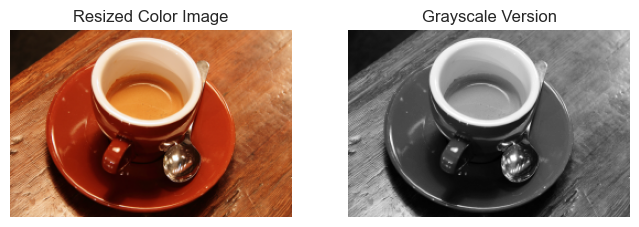


✅ Step 3.3: Preprocessing complete
Final working dimensions: 256x170 pixels


In [81]:
# Get resized dimensions for later use
resized_h, resized_w = img_rgb_resized.shape[:2]

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(img_rgb_resized)
axes[0].set_title("Resized Color Image")
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray")
axes[1].set_title("Grayscale Version")
axes[1].axis("off")
plt.show()

print("\n✅ Step 3.3: Preprocessing complete")
print(f"Final working dimensions: {resized_w}x{resized_h} pixels")

# <a id='toc6_'></a>[Step 4: Corner Response Calculation](#toc0_)

## <a id='toc6_1_'></a>[Step 4.1: Understand the Harris Response Formula](#toc0_)

The Harris algorithm calculates a "corner score" for each pixel using the structure tensor $M$ (from Step 0.2) and its eigenvalues ($\lambda_1, \lambda_2$):

$$R = \det(M) - k \cdot \text{trace}(M)^2$$
Where:
- $\det(M) = \lambda_1 \lambda_2$ (product of eigenvalues)
- $\text{trace}(M) = \lambda_1 + \lambda_2$ (sum of eigenvalues)
- $k = Sensitivity factor$ (typically 0.04–0.06; controls corner vs edge classification)

For corners: $R$ is large and positive (both $\lambda_1, \lambda_2$ are large).

## <a id='toc6_2_'></a>[Step 4.2: Calculate the Corner Response Matrix](#toc0_)
Use corner_harris() to compute the response values for every pixel in the grayscale image.

In [82]:
# Calculate corner response using Harris algorithm
corner_response = corner_harris(
    image=img_gray,
    k=0.03,  # Lower than default (0.05) to detect more potential corners
    sigma=0.6  # Small Gaussian blur to reduce noise while preserving details
)

## <a id='toc6_3_'></a>[Step 4.3: Visualize the Response Matrix](#toc0_)
The response matrix is the same size as the grayscale image, with brighter values indicating stronger corner likelihood.

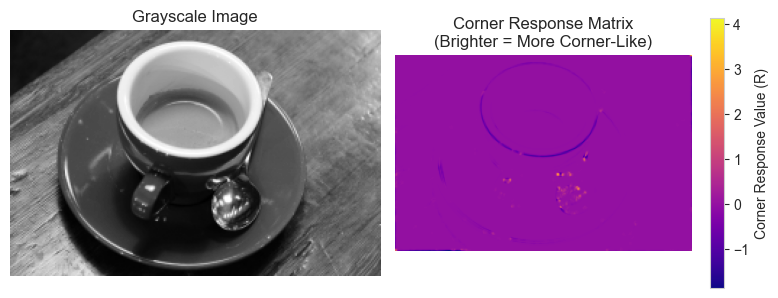

In [83]:
# Compare grayscale image with its corner response matrix
plt.figure(figsize=(8, 3))

# Plot 1: Grayscale image (input)
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

# Plot 2: Corner response matrix (output)
plt.subplot(1, 2, 2)
plt.imshow(corner_response, cmap="plasma")  # Plasma colormap highlights high values
plt.colorbar(label="Corner Response Value (R)")
plt.title("Corner Response Matrix\n(Brighter = More Corner-Like)")
plt.axis("off")

plt.tight_layout()
plt.show()

## <a id='toc6_4_'></a>[Step 4.4: Analyze Response Matrix Properties](#toc0_)
Check the shape and value range to confirm the response matrix is valid and captures meaningful corner signals.

In [84]:
print("\n✅ Step 4: Corner response matrix generated")
print(f"Response shape: {corner_response.shape} (matches grayscale image: {img_gray.shape})")
print(f"Minimum response value: {corner_response.min():.4f} (non-corner regions)")
print(f"Maximum response value: {corner_response.max():.4f} (strongest corners)")
print(f"Mean response value: {corner_response.mean():.4f} (average 'corner-ness')")


✅ Step 4: Corner response matrix generated
Response shape: (170, 256) (matches grayscale image: (170, 256))
Minimum response value: -1.8587 (non-corner regions)
Maximum response value: 4.1413 (strongest corners)
Mean response value: -0.0081 (average 'corner-ness')


# <a id='toc7_'></a>[Step 5: Extract Corner Peaks](#toc0_)

## <a id='toc7_1_'></a>[Step 5.1: What are Corner Peaks?](#toc0_)

`corner_peaks()` selects pixels with locally maximum values from the corner_response matrix. It acts as a "filter" to:

- Ignore pixels with weak responses (below threshold_rel)
- Ensure corners are not too close together (enforced by min_distance)
- Only keep pixels that are brighter than all neighboring pixels (local maxima)

## <a id='toc7_2_'></a>[Step 5.2: Configure Peak Detection Parameters](#toc0_)
The corner_peaks() function uses two key parameters to filter peaks:

<table style="border-collapse: collapse; width: 100%; margin: 15px 0; border: 1px solid #ddd;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="border: 1px solid #ddd; padding: 12px; text-align: left; font-weight: bold;">Parameter</th>
      <th style="border: 1px solid #ddd; padding: 12px; text-align: left; font-weight: bold;">Purpose</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ddd; padding: 12px;"><code>threshold_rel</code></td>
      <td style="border: 1px solid #ddd; padding: 12px;">Minimum response strength (relative to the maximum response in the image). Lower values = more peaks.</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="border: 1px solid #ddd; padding: 12px;"><code>min_distance</code></td>
      <td style="border: 1px solid #ddd; padding: 12px;">Minimum number of pixels between peaks. Smaller values = more densely packed peaks.</td>
    </tr>
  </tbody>
</table>

In [85]:
# Extract peaks with aggressive settings to maximize corner count
corners = corner_peaks(
    corner_response,
    min_distance=1,  # Allow peaks to be adjacent (1 pixel apart)
    threshold_rel=0.005  # Keep peaks with response > 0.5% of the maximum response
)

## <a id='toc7_3_'></a>[Step 5.3: Visualize Peak Selection](#toc0_)
Overlay the detected peaks on the corner response matrix to see how they correspond to high-response regions.

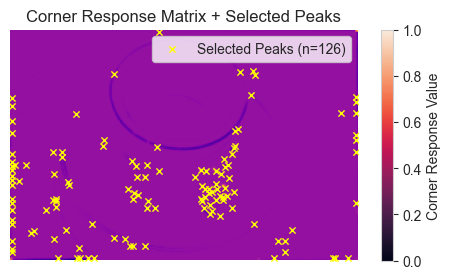

In [86]:
plt.figure(figsize=(6, 3))
# Show the corner response matrix as a heatmap
plt.imshow(corner_response, cmap="plasma")
# Overlay detected peaks (yellow 'X' markers)
plt.scatter(
    x=corners[:, 1],  # Column = x-axis
    y=corners[:, 0],  # Row = y-axis
    color="yellow",
    s=20,
    marker="x",
    linewidth=1,
    label=f"Selected Peaks (n={len(corners)})"
)
plt.colorbar(label="Corner Response Value")
plt.title("Corner Response Matrix + Selected Peaks")
plt.legend(loc="upper right")
plt.axis("off")
plt.show()

## <a id='toc7_4_'></a>[Step 5.4: Analyze Detected Corners](#toc0_)
Review the number and coordinates of the detected peaks to confirm they align with expected features (e.g., cup edges, handle, saucer).

In [87]:
print("\n✅ Step 5: Corner peaks extracted")
print(f"Total corners detected: {len(corners)}")
print("First 5 corner coordinates (row, column):\n", corners[:5])


✅ Step 5: Corner peaks extracted
Total corners detected: 126
First 5 corner coordinates (row, column):
 [[103 140]
 [116 158]
 [104 144]
 [ 91 163]
 [108  99]]


In [88]:
# Verify coordinate range matches the image size
print(f"Coordinate range:")
print(f"  Rows (y): {corners[:, 0].min()} to {corners[:, 0].max()} (image height: {resized_h})")
print(f"  Columns (x): {corners[:, 1].min()} to {corners[:, 1].max()} (image width: {resized_w})")

Coordinate range:
  Rows (y): 1 to 168 (image height: 170)
  Columns (x): 1 to 254 (image width: 256)


# <a id='toc8_'></a>[Step 6: Visualize Corners with High-Contrast Markers](#toc0_)

## <a id='toc8_1_'></a>[Step 6.1: Choose Marker Style for Visibility](#toc0_)
To make corners stand out against the coffee’s brown tones, we select:
- `Cyan (#00FFFF)` for the marker color (opposite brown on the color wheel).
- A small circular marker (o) with a thin black border (to improve edge definition).
- A modest size ($s=15$) to avoid obscuring image details.

## <a id='toc8_2_'></a>[Step 6.2: Overlay Corners on the Resized Image](#toc0_)
Plot the detected corner coordinates on top of the resized color image to see their real-world positions.

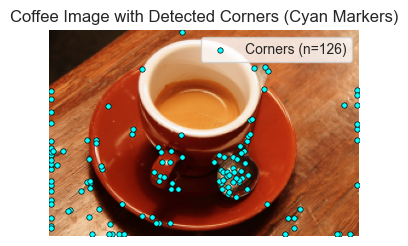

In [89]:
plt.figure(figsize=(4, 3))
plt.imshow(img_rgb_resized)
plt.scatter(
    x=corners[:, 1], y=corners[:, 0],
    color="#00FFFF",  # Cyan color code
    s=15, 
    marker="o", 
    edgecolors="black",  # Black border for extra visibility
    linewidth=0.5,
    label=f"Corners (n={len(corners)})"
)
plt.title("Coffee Image with Detected Corners (Cyan Markers)")
plt.legend()
plt.axis("off")
plt.show()

# <a id='toc9_'></a>[Step 7: Analyze Valid ROIs](#toc0_)

## <a id='toc9_1_'></a>[Step 7.1: Define Key Regions of Interest (ROIs)](#toc0_)
- We select 5 meaningful ROIs targeting distinct features of the coffee scene.
- Coordinates are dynamically calculated using percentages of resized dimensions
- to ensure compatibility with any image size

In [90]:
# Define ROI data with color information
roi_data = [
    {
        "number": 1,
        "feature": "Cup rim",
        "h_start": 0.05,
        "h_end": 0.30,
        "w_start": 0.25,
        "w_end": 0.70,
        "color": (255, 0, 0)  # Red
    },
    {
        "number": 2,
        "feature": "Handle",
        "h_start": 0.50,
        "h_end": 0.80,
        "w_start": 0.30,
        "w_end": 0.50,
        "color": (0, 255, 0)  # Green
    },
    {
        "number": 3,
        "feature": "Saucer edge",
        "h_start": 0.20,
        "h_end": 0.90,
        "w_start": 0.10,
        "w_end": 0.20,
        "color": (0, 0, 255)  # Blue
    },
    {
        "number": 4,
        "feature": "Spoon",
        "h_start": 0.55,
        "h_end": 0.80,
        "w_start": 0.55,
        "w_end": 0.70,
        "color": (255, 255, 0)  # Yellow
    },
    {
        "number": 5,
        "feature": "Background contrast",
        "h_start": 0.10,
        "h_end": 0.30,
        "w_start": 0.75,
        "w_end": 0.95,
        "color": (255, 0, 255)  # Magenta
    }
]

# Calculate ROIs using the structured data
rois = []
for roi in roi_data:
    rois.append((
        int(resized_h * roi["h_start"]),
        int(resized_h * roi["h_end"]),
        int(resized_w * roi["w_start"]),
        int(resized_w * roi["w_end"])
    ))

## <a id='toc9_2_'></a>[Step 7.2: Display the image with ROIs](#toc0_)

In [91]:
# Create a copy of the resized image to draw on
image_with_rois = img_rgb_resized.copy()

# Draw each ROI on the image
for roi in roi_data:
    # Get ROI coordinates
    y1 = int(resized_h * roi["h_start"])
    y2 = int(resized_h * roi["h_end"])
    x1 = int(resized_w * roi["w_start"])
    x2 = int(resized_w * roi["w_end"])
    
    # Draw rectangle with 2px thickness
    cv2.rectangle(
        image_with_rois, 
        (x1, y1),  # Top-left corner
        (x2, y2),  # Bottom-right corner
        roi["color"],
        2  # Line thickness
    )
    
    # Add ROI label with smaller font (fontScale reduced to 0.35)
    cv2.putText(
        image_with_rois,
        f"ROI {roi['number']}",
        (x1 + 5, y1 + 15),  # Slightly adjusted vertical position for smaller text
        cv2.FONT_HERSHEY_SIMPLEX,
        0.35,  # Reduced font size
        roi["color"],
        1  # Reduced font thickness to match smaller size
    )

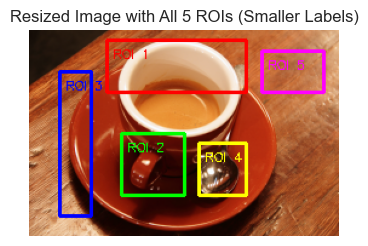

✅ Step 7.2: ROIs defined and visualized with smaller label font


In [92]:
# Display the image with ROIs
plt.figure(figsize=(4, 3))
plt.imshow(image_with_rois)
plt.title("Resized Image with All 5 ROIs (Smaller Labels)")
plt.axis("off")
plt.show()

print("✅ Step 7.2: ROIs defined and visualized with smaller label font")

## <a id='toc9_3_'></a>[Step 7.3: ROI Feature Targets Reference Table](#toc0_)

In [93]:
# Print ROI feature targets with rounded percentages
print("📌 Step 7.3: ROI Feature Targets")
print("-" * 110)
print(f"{'ROI Number':<12} {'Feature Targeted':<25} {'Coordinate Logic (using variables)':<70}")
print("-" * 110)

# Loop through roi_data with rounded percentages
for roi in roi_data:
    print(f"{roi['number']:<12} {roi['feature']:<25} "
          f"{round(roi['h_start']*100, 1)}%-{round(roi['h_end']*100, 1)}% of resized_h, "
          f"{round(roi['w_start']*100, 1)}%-{round(roi['w_end']*100, 1)}% of resized_w")

print("-" * 110)

📌 Step 7.3: ROI Feature Targets
--------------------------------------------------------------------------------------------------------------
ROI Number   Feature Targeted          Coordinate Logic (using variables)                                    
--------------------------------------------------------------------------------------------------------------
1            Cup rim                   5.0%-30.0% of resized_h, 25.0%-70.0% of resized_w
2            Handle                    50.0%-80.0% of resized_h, 30.0%-50.0% of resized_w
3            Saucer edge               20.0%-90.0% of resized_h, 10.0%-20.0% of resized_w
4            Spoon                     55.0%-80.0% of resized_h, 55.0%-70.0% of resized_w
5            Background contrast       10.0%-30.0% of resized_h, 75.0%-95.0% of resized_w
--------------------------------------------------------------------------------------------------------------


## <a id='toc9_4_'></a>[Step 7.4: Verify ROI Coordinates](#toc0_)

In [94]:
# Print the actual pixel coordinates for each ROI to confirm valid ranges
print("\n✅ Step 7.4: Calculated ROI Coordinates")
print(f"Based on resized image dimensions: {resized_w}x{resized_h} (width x height)")
print("Format: (y1, y2, x1, x2) where:")
print("- y1, y2: Vertical range (top to bottom)")
print("- x1, x2: Horizontal range (left to right)")
print("-" * 60)


✅ Step 7.4: Calculated ROI Coordinates
Based on resized image dimensions: 256x170 (width x height)
Format: (y1, y2, x1, x2) where:
- y1, y2: Vertical range (top to bottom)
- x1, x2: Horizontal range (left to right)
------------------------------------------------------------


In [95]:
for i, (y1, y2, x1, x2) in enumerate(rois, 1):
    print(f"ROI {i}: ({y1}, {y2}, {x1}, {x2})")
    print(f"  Vertical range: {y2 - y1} pixels")
    print(f"  Horizontal range: {x2 - x1} pixels")
    print("-" * 60)

ROI 1: (8, 51, 64, 179)
  Vertical range: 43 pixels
  Horizontal range: 115 pixels
------------------------------------------------------------
ROI 2: (85, 136, 76, 128)
  Vertical range: 51 pixels
  Horizontal range: 52 pixels
------------------------------------------------------------
ROI 3: (34, 153, 25, 51)
  Vertical range: 119 pixels
  Horizontal range: 26 pixels
------------------------------------------------------------
ROI 4: (93, 136, 140, 179)
  Vertical range: 43 pixels
  Horizontal range: 39 pixels
------------------------------------------------------------
ROI 5: (17, 51, 192, 243)
  Vertical range: 34 pixels
  Horizontal range: 51 pixels
------------------------------------------------------------


## <a id='toc9_5_'></a>[Step 7.5: Visualize Corners in Each ROI](#toc0_)
Create a grid of subplots to show each ROI with its detected corners

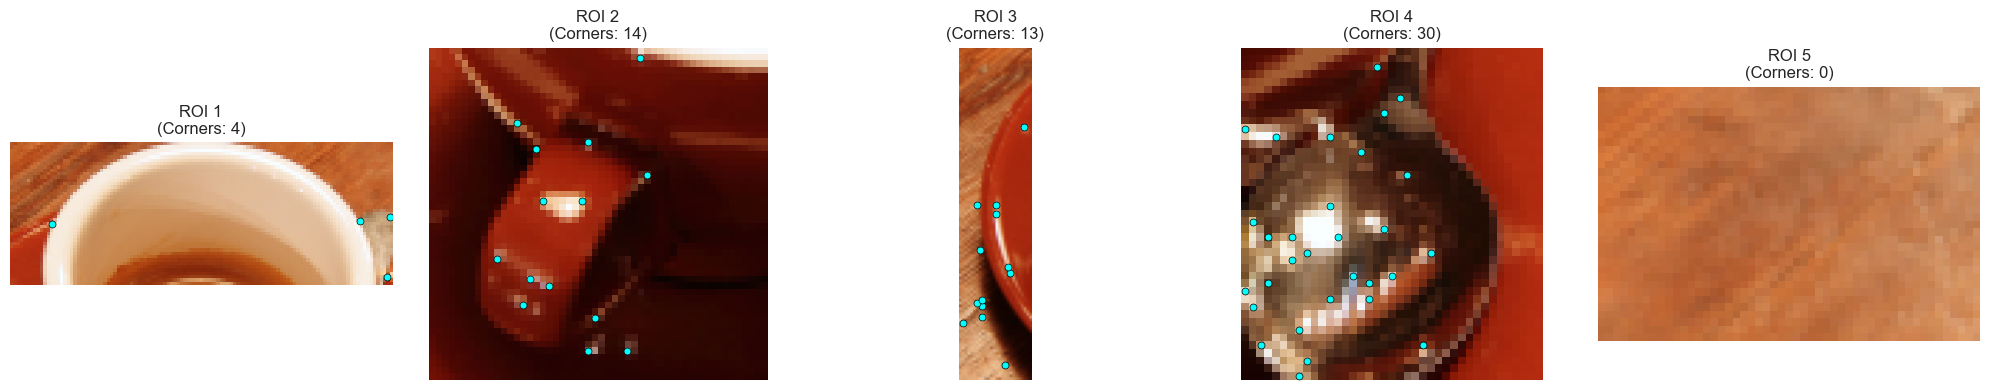

In [96]:
# Create a 1x5 grid of subplots (one for each ROI)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Process each ROI
for i, (y1, y2, x1, x2) in enumerate(rois):
    # Crop the ROI from the resized color image
    roi_img = img_rgb_resized[y1:y2, x1:x2]
    
    # Filter corners that fall within this ROI
    roi_corners = corners[
        (corners[:, 0] >= y1) & (corners[:, 0] <= y2) &  # Rows within ROI height
        (corners[:, 1] >= x1) & (corners[:, 1] <= x2)    # Columns within ROI width
    ]
    
    # Plot the ROI image
    axes[i].imshow(roi_img)
    
    # Overlay corners with coordinates adjusted to the ROI's local frame
    axes[i].scatter(
        x=roi_corners[:, 1] - x1,  # Subtract x1 to align with ROI's left edge
        y=roi_corners[:, 0] - y1,  # Subtract y1 to align with ROI's top edge
        color="#00FFFF",  # Cyan color for high contrast against brown
        s=25,             # Marker size
        marker="o",       # Circular marker
        edgecolors="black",  # Black border for better visibility
        linewidth=0.5
    )
    
    # Add title with ROI number and corner count
    axes[i].set_title(f"ROI {i+1}\n(Corners: {len(roi_corners)})")
    axes[i].axis("off")  # Hide axes for cleaner visualization

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## <a id='toc9_6_'></a>[Step 7.6: Analyze and Interpret ROI Results](#toc0_)
Summarize findings and validate corner detection quality

In [97]:
print("\n📊 Step 7.6: ROI Analysis Results")  # Fixed duplicate Step 7.5 label
print("-" * 70)

# Calculate and print corner statistics per ROI (unchanged)
total_corners = len(corners)
for i, (y1, y2, x1, x2) in enumerate(rois, 1):
    roi_corners = corners[
        (corners[:, 0] >= y1) & (corners[:, 0] <= y2) &
        (corners[:, 1] >= x1) & (corners[:, 1] <= x2)
    ]
    roi_count = len(roi_corners)
    roi_percent = (roi_count / total_corners) * 100 if total_corners > 0 else 0
    print(f"ROI {i}: {roi_count} corner(s) ({roi_percent:.1f}% of total)")


📊 Step 7.6: ROI Analysis Results
----------------------------------------------------------------------
ROI 1: 4 corner(s) (3.2% of total)
ROI 2: 14 corner(s) (11.1% of total)
ROI 3: 13 corner(s) (10.3% of total)
ROI 4: 30 corner(s) (23.8% of total)
ROI 5: 0 corner(s) (0.0% of total)


In [98]:

print("-" * 70)

print("Interpretation Guidelines:")
print("1. ROI 1 (Cup rim): Should have a continuous line of corners following the curve")
print("2. ROI 2 (Handle): Expect clusters at attachment points and along the curved edge")
print("3. ROI 3 (Saucer edge): Should show dense corners along the outer rim")
print("4. ROI 4 (Spoon): Expect corners along the spoon’s handle and bowl edges (high contrast vs. saucer)")  # Updated
print("5. ROI 5 (Background): Sparse corners, primarily where background contrasts with cup")

----------------------------------------------------------------------
Interpretation Guidelines:
1. ROI 1 (Cup rim): Should have a continuous line of corners following the curve
2. ROI 2 (Handle): Expect clusters at attachment points and along the curved edge
3. ROI 3 (Saucer edge): Should show dense corners along the outer rim
4. ROI 4 (Spoon): Expect corners along the spoon’s handle and bowl edges (high contrast vs. saucer)
5. ROI 5 (Background): Sparse corners, primarily where background contrasts with cup
